In [1]:
# ============================================
# 🩸 RAKTCONNECT — Install Required Libraries
# ============================================

!pip install pandas numpy matplotlib seaborn

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
# ============================================
# 🩸 RAKTCONNECT — Import Libraries
# ============================================

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🩸 RAKTCONNECT — AI Emergency Blood Donor Network")
print("=" * 60)
print("📊 CodeStorm 2026 — FutureForge")
print("=" * 60)

🩸 RAKTCONNECT — AI Emergency Blood Donor Network
📊 CodeStorm 2026 — FutureForge


In [3]:
# ============================================
# STEP 1: UPLOAD DATASET
# ============================================

print("\n📥 STEP 1: Please upload your Blood Donor Dataset...")

uploaded = files.upload()

# Get the filename
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"\n✅ Dataset Loaded Successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns:")
for col in df.columns:
    print(f"   - {col}")

print("\n🔍 First 5 rows:")
display(df.head())


📥 STEP 1: Please upload your Blood Donor Dataset...


Saving blood_donation.csv to blood_donation.csv

✅ Dataset Loaded Successfully!
📊 Shape: 10000 rows × 18 columns

📋 Columns:
   - Donor_ID
   - Full_Name
   - Gender
   - Age
   - Blood_Group
   - Contact_Number
   - Email
   - City
   - State
   - Country
   - Last_Donation_Date
   - Total_Donations
   - Eligible_for_Donation
   - Medical_Condition
   - Weight_kg
   - Hemoglobin_g_dL
   - Donation_Center
   - Registration_Date

🔍 First 5 rows:


,Donor_ID,Full_Name,Gender,Age,Blood_Group,Contact_Number,Email,City,State,Country,Last_Donation_Date,Total_Donations,Eligible_for_Donation,Medical_Condition,Weight_kg,Hemoglobin_g_dL,Donation_Center,Registration_Date
0,DNR000001,Sangeeta Menon,Female,38,O+,1819600042,sangeeta.menon8280@gmail.com,Kolkata,West Bengal,India,07-10-2025,1,Yes,NaN,66.6,13.6,Red Cross Blood Bank,02-07-2021
1,DNR000002,Meena Iyer,Female,49,B+,265423420,meena.iyer6225@gmail.com,Jaipur,Rajasthan,India,08-11-2020,1,No,Hypertension,70.8,14.0,Metro Blood Bank,03-03-2023
2,DNR000003,Priya Nair,Female,29,B+,1849593012,priya.nair4742@gmail.com,Gurgaon,Haryana,India,12-04-2025,2,No,Diabetes,73.4,12.5,Fortis Blood Bank,15-10-2015
3,DNR000004,Vijay Kapoor,Male,29,O+,3419283185,vijay.kapoor4423@gmail.com,Thiruvananthapuram,Kerala,India,21-02-2025,1,Yes,NaN,57.9,14.8,NABL Blood Centre,09-05-2022
4,DNR000005,Rahul Iyer,Male,27,A+,6413953676,rahul.iyer2341@gmail.com,Bhopal,Madhya Pradesh,India,18-04-2024,1,Yes,NaN,74.0,17.1,NABL Blood Centre,13-07-2022


In [4]:
# ============================================
# STEP 2: DATA EXPLORATION
# ============================================

print("\n📊 STEP 2: Data Exploration...")

print("\n📋 Data Types:")
print(df.dtypes)

print("\n📊 Statistical Summary:")
display(df.describe())

print("\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_percent
})
display(missing_df[missing_df['Missing_Count'] > 0])


📊 STEP 2: Data Exploration...

📋 Data Types:
Donor_ID                  object
Full_Name                 object
Gender                    object
Age                        int64
Blood_Group               object
Contact_Number             int64
Email                     object
City                      object
State                     object
Country                   object
Last_Donation_Date        object
Total_Donations            int64
Eligible_for_Donation     object
Medical_Condition         object
Weight_kg                float64
Hemoglobin_g_dL          float64
Donation_Center           object
Registration_Date         object
dtype: object

📊 Statistical Summary:


,Age,Contact_Number,Total_Donations,Weight_kg,Hemoglobin_g_dL
count,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.00000
mean,33.897800,5.028221e+09,2.084800,68.015560,13.73798
std,9.417071,2.876037e+09,1.324003,10.014265,1.26601
min,18.000000,3.639000e+05,0.000000,45.000000,10.00000
25%,27.000000,2.538943e+09,1.000000,61.100000,12.80000
50%,34.000000,5.060247e+09,2.000000,67.900000,13.70000
75%,40.000000,7.494996e+09,3.000000,74.900000,14.60000
max,65.000000,9.998636e+09,9.000000,110.000000,18.00000



🔍 Missing Values:


,Missing_Count,Percentage
Medical_Condition,7805,78.05


In [5]:
# ============================================
# STEP 3: DATA CLEANING
# ============================================

print("\n🧹 STEP 3: Data Cleaning...")

original_shape = df.shape

# 3.1 Handle Missing Values
print("\n📌 3.1 Handling Missing Values...")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].mean(), inplace=True)
            print(f"   ✅ Filled missing in '{col}' with Mean")
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"   ✅ Filled missing in '{col}' with Mode")

# 3.2 Remove Duplicates
print("\n📌 3.2 Checking for Duplicates...")
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"   ✅ Removed {duplicates} duplicate rows")
else:
    print("   ✅ No duplicates found")

# 3.3 Handle Outliers
print("\n📌 3.3 Handling Outliers using IQR method...")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f"   ✅ Capped {len(outliers)} outliers in '{col}'")
    else:
        print(f"   ✅ No outliers in '{col}'")

print(f"\n✅ Cleaning Complete!")
print(f"   Original Size: {original_shape}")
print(f"   New Size: {df.shape}")


🧹 STEP 3: Data Cleaning...

📌 3.1 Handling Missing Values...
   ✅ Filled missing in 'Medical_Condition' with Mode

📌 3.2 Checking for Duplicates...
   ✅ No duplicates found

📌 3.3 Handling Outliers using IQR method...
   ✅ Capped 42 outliers in 'Age'
   ✅ No outliers in 'Contact_Number'
   ✅ Capped 49 outliers in 'Total_Donations'
   ✅ Capped 27 outliers in 'Weight_kg'
   ✅ Capped 28 outliers in 'Hemoglobin_g_dL'

✅ Cleaning Complete!
   Original Size: (10000, 18)
   New Size: (10000, 18)


In [6]:
# ============================================
# STEP 4: SAVE CLEANED DATASET
# ============================================

print("\n💾 STEP 4: Saving Cleaned Dataset...")

cleaned_file = 'cleaned_blood_donor_dataset.csv'
df.to_csv(cleaned_file, index=False)
print(f"✅ Cleaned dataset saved as: {cleaned_file}")

# Download the cleaned dataset
files.download(cleaned_file)


💾 STEP 4: Saving Cleaned Dataset...
✅ Cleaned dataset saved as: cleaned_blood_donor_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📊 STEP 5: Creating Visualizations...
✅ Visualization saved as 'visualization_report.png'


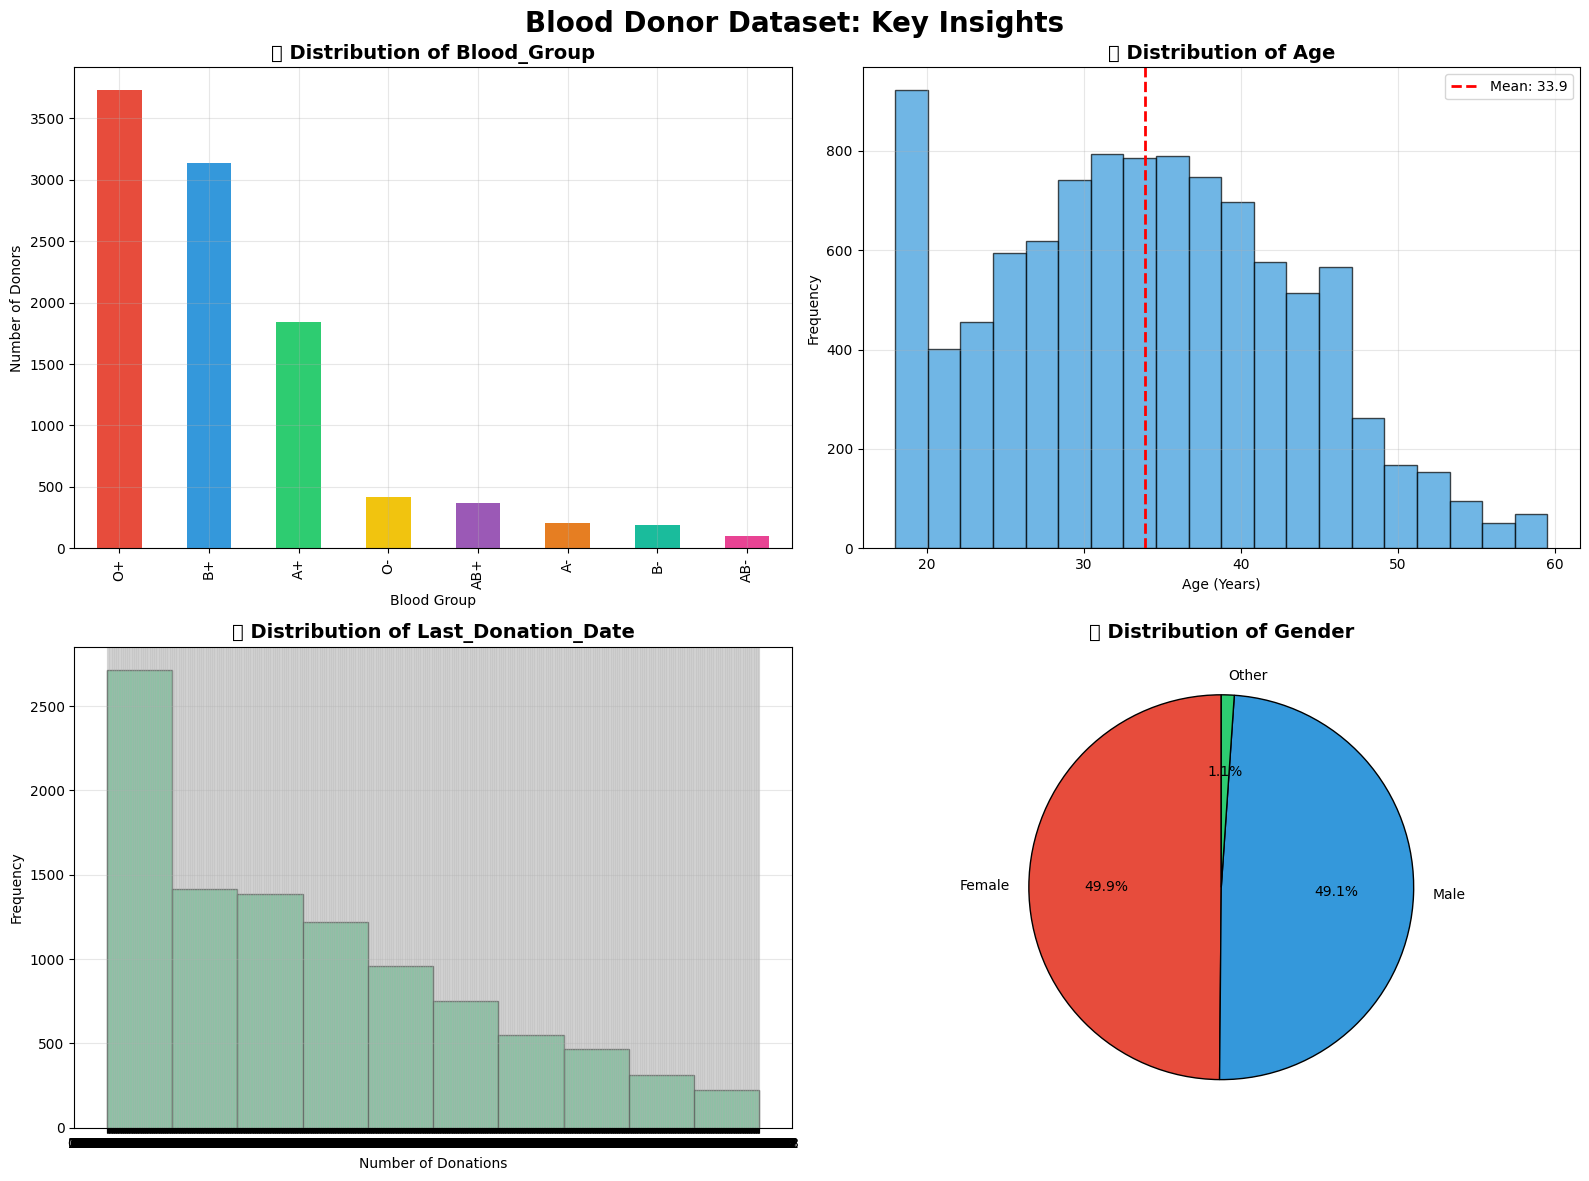

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# ============================================
# STEP 5: VISUALIZATIONS
# ============================================

print("\n📊 STEP 5: Creating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Blood Donor Dataset: Key Insights', fontsize=20, fontweight='bold')

# Graph 1: Blood Group Distribution
blood_col = None
for col in df.columns:
    if 'blood' in col.lower() or 'group' in col.lower():
        blood_col = col
        break

if blood_col:
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6', '#e67e22', '#1abc9c', '#e84393']
    df[blood_col].value_counts().plot(
        kind='bar', ax=axes[0,0], color=colors[:len(df[blood_col].value_counts())]
    )
    axes[0,0].set_title(f'🩸 Distribution of {blood_col}', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Blood Group')
    axes[0,0].set_ylabel('Number of Donors')
    axes[0,0].grid(True, alpha=0.3)

# Graph 2: Age Distribution
age_col = None
for col in df.columns:
    if 'age' in col.lower():
        age_col = col
        break

if age_col:
    axes[0,1].hist(df[age_col].dropna(), bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0,1].set_title(f'📊 Distribution of {age_col}', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Age (Years)')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].axvline(df[age_col].mean(), color='red', linestyle='dashed', linewidth=2,
                      label=f'Mean: {df[age_col].mean():.1f}')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# Graph 3: Donation Count
donation_col = None
for col in df.columns:
    if 'donation' in col.lower() or 'times' in col.lower():
        donation_col = col
        break

if donation_col:
    axes[1,0].hist(df[donation_col].dropna(), bins=10, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[1,0].set_title(f'📊 Distribution of {donation_col}', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Number of Donations')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].grid(True, alpha=0.3)

# Graph 4: Gender/City Distribution
gender_col = None
for col in df.columns:
    if 'gender' in col.lower() or 'sex' in col.lower():
        gender_col = col
        break

if gender_col:
    df[gender_col].value_counts().plot(
        kind='pie', ax=axes[1,1], autopct='%1.1f%%',
        colors=['#e74c3c', '#3498db', '#2ecc71'],
        startangle=90, wedgeprops={'edgecolor': 'black'}
    )
    axes[1,1].set_title(f'📊 Distribution of {gender_col}', fontsize=14, fontweight='bold')
    axes[1,1].set_ylabel('')
elif 'city' in df.columns:
    df['city'].value_counts().head(10).plot(
        kind='barh', ax=axes[1,1], color='#e67e22'
    )
    axes[1,1].set_title('🏙️ Top 10 Cities by Donors', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Number of Donors')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualization_report.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved as 'visualization_report.png'")
plt.show()

# Download the visualization
files.download('visualization_report.png')

In [8]:
# ============================================
# STEP 6: AI MATCHING ENGINE
# ============================================

print("\n🤖 STEP 6: Setting up AI Matching Engine...")

# Indian cities with coordinates
indian_cities = {
    'Delhi': (28.6139, 77.2090),
    'Mumbai': (19.0760, 72.8777),
    'Chennai': (13.0827, 80.2707),
    'Bangalore': (12.9716, 77.5946),
    'Hyderabad': (17.3850, 78.4867),
    'Kolkata': (22.5726, 88.3639),
    'Pune': (18.5204, 73.8567),
    'Ahmedabad': (23.0225, 72.5714),
    'Jaipur': (26.9124, 75.7873),
    'Lucknow': (26.8467, 80.9462)
}

# Add coordinates if not present
if 'latitude' not in df.columns or 'longitude' not in df.columns:
    if 'city' in df.columns:
        df['latitude'] = df['city'].apply(
            lambda x: indian_cities.get(x, (28.6139, 77.2090))[0]
        )
        df['longitude'] = df['city'].apply(
            lambda x: indian_cities.get(x, (28.6139, 77.2090))[1]
        )
        print("✅ Added latitude/longitude based on city")
    else:
        df['latitude'] = np.random.uniform(8.0, 35.0, len(df))
        df['longitude'] = np.random.uniform(68.0, 97.0, len(df))
        print("✅ Added random latitude/longitude")

# Map blood group column
blood_col = None
for col in df.columns:
    if 'blood' in col.lower() or 'group' in col.lower():
        blood_col = col
        break

if blood_col:
    df.rename(columns={blood_col: 'blood_group'}, inplace=True)
    print(f"✅ Blood group column found: 'blood_group'")
else:
    blood_groups = ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
    df['blood_group'] = np.random.choice(blood_groups, len(df))
    print("✅ Created blood group column")

# Map availability column
avail_col = None
for col in df.columns:
    if 'available' in col.lower() or 'eligible' in col.lower() or 'status' in col.lower():
        avail_col = col
        break

if avail_col:
    df.rename(columns={avail_col: 'availability'}, inplace=True)
    df['availability'] = df['availability'].apply(
        lambda x: 'Yes' if str(x).lower() in ['yes', 'true', '1', 'available', 'eligible'] else 'No'
    )
    print("✅ Availability column found")
else:
    df['availability'] = np.random.choice(['Yes', 'Yes', 'Yes', 'No'], len(df))
    print("✅ Created availability column")

print(f"\n📊 Total donors: {len(df)}")
print(f"📊 Available donors: {len(df[df['availability'] == 'Yes'])}")


🤖 STEP 6: Setting up AI Matching Engine...
✅ Added random latitude/longitude
✅ Blood group column found: 'blood_group'
✅ Availability column found

📊 Total donors: 10000
📊 Available donors: 6416


In [9]:
# ============================================
# STEP 7: BLOOD COMPATIBILITY MATRIX
# ============================================

print("\n🧬 STEP 7: Blood Compatibility Matrix...")

compatibility_matrix = {
    'A+': ['A+', 'AB+'],
    'A-': ['A+', 'A-', 'AB+', 'AB-'],
    'B+': ['B+', 'AB+'],
    'B-': ['B+', 'B-', 'AB+', 'AB-'],
    'AB+': ['AB+'],
    'AB-': ['AB+', 'AB-'],
    'O+': ['A+', 'B+', 'AB+', 'O+'],
    'O-': ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-']
}

def get_compatible_groups(patient_blood):
    return compatibility_matrix.get(patient_blood.upper(), [])

print("✅ Compatibility matrix ready!")
print("\n📊 Blood Compatibility Rules:")
print("🩸 O- is the Universal Donor (can donate to ALL groups)")
print("❤️ AB+ is the Universal Recipient (can receive from ALL groups)")

if 'blood_group' in df.columns:
    print("\n📊 Blood Group Distribution:")
    print(df['blood_group'].value_counts())


🧬 STEP 7: Blood Compatibility Matrix...
✅ Compatibility matrix ready!

📊 Blood Compatibility Rules:
🩸 O- is the Universal Donor (can donate to ALL groups)
❤️ AB+ is the Universal Recipient (can receive from ALL groups)

📊 Blood Group Distribution:
blood_group
O+     3729
B+     3136
A+     1842
O-      419
AB+     371
A-      208
B-      194
AB-     101
Name: count, dtype: int64


In [10]:
# ============================================
# STEP 8: HAVERSINE DISTANCE FUNCTION
# ============================================

print("\n📍 STEP 8: Distance Calculator...")

def haversine(lat1, lon1, lat2, lon2):
    """Calculate distance between two coordinates in kilometers"""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Test the function
test_distance = haversine(28.6139, 77.2090, 19.0760, 72.8777)
print(f"✅ Distance calculator ready!")
print(f"📍 Distance between Delhi and Mumbai: {test_distance:.1f} km")


📍 STEP 8: Distance Calculator...
✅ Distance calculator ready!
📍 Distance between Delhi and Mumbai: 1148.1 km


In [11]:
# ============================================
# STEP 9: AI MATCHING ENGINE
# ============================================

print("\n🤖 STEP 9: AI Matching Engine...")

def find_donors(patient_lat, patient_lon, patient_blood, urgency='normal', max_donors=5):
    """Find and rank compatible donors"""
    compatible_groups = get_compatible_groups(patient_blood)

    # Filter compatible + available donors
    compatible = df[
        (df['blood_group'].str.upper().isin(compatible_groups)) &
        (df['availability'] == 'Yes')
    ].copy()

    if len(compatible) == 0:
        return None, 0, "❌ No compatible donors found!"

    # Calculate distance
    compatible['distance_km'] = compatible.apply(
        lambda row: haversine(patient_lat, patient_lon, row['latitude'], row['longitude']),
        axis=1
    )

    # Sort by distance
    compatible = compatible.sort_values('distance_km')

    # Priority scoring
    urgency_multiplier = {
        'critical': 0.3,
        'urgent': 0.6,
        'normal': 1.0
    }

    compatible['priority_score'] = compatible['distance_km'] / 5
    compatible['priority_score'] = compatible['priority_score'] * urgency_multiplier.get(urgency.lower(), 1.0)
    compatible = compatible.sort_values('priority_score')

    return compatible.head(max_donors), len(compatible), "✅ Donors found!"

print("✅ AI Matching Engine ready!")

# Test the engine
test_donors, total, status = find_donors(28.6139, 77.2090, "O+", "normal")
print(f"\n🧪 Test: Finding O+ donors near Delhi")
print(f"📊 {status}")
print(f"📊 Total compatible donors: {total}")
if test_donors is not None:
    print(f"📊 Top donor: {test_donors.iloc[0]['blood_group']} at {test_donors.iloc[0]['distance_km']:.1f} km")


🤖 STEP 9: AI Matching Engine...
✅ AI Matching Engine ready!

🧪 Test: Finding O+ donors near Delhi
📊 ✅ Donors found!
📊 Total compatible donors: 5800
📊 Top donor: B+ at 28.2 km


In [12]:
# ============================================
# STEP 10: EMERGENCY REQUEST SYSTEM
# ============================================

print("\n🚨 STEP 10: Emergency Request System...")

def emergency_request(patient_name, blood_group, city, urgency='normal'):
    """Simulate an emergency blood request"""
    if city in indian_cities:
        lat, lon = indian_cities[city]
    else:
        lat, lon = 28.6139, 77.2090
        print(f"⚠️ City '{city}' not found! Using Delhi as default.")

    print("\n" + "=" * 60)
    print(f"🆘 EMERGENCY BLOOD REQUEST")
    print("=" * 60)
    print(f"👤 Patient: {patient_name}")
    print(f"🩸 Blood Group: {blood_group.upper()}")
    print(f"📍 Location: {city}")
    print(f"🚨 Urgency: {urgency.upper()}")
    print("=" * 60)

    donors, total, status = find_donors(lat, lon, blood_group, urgency)

    if donors is None:
        print(f"\n{status}")
        print("🚨 Escalating to hospital network & blood banks...")
        return None

    print(f"\n{status}")
    print(f"📊 Total compatible donors: {total}")
    print(f"🏆 Top {len(donors)} donors:\n")

    for idx, (_, donor) in enumerate(donors.iterrows(), 1):
        emoji = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "📍"
        name = donor.get('name', 'Donor')
        blood = donor.get('blood_group', 'Unknown')
        distance = donor.get('distance_km', 0)
        phone = donor.get('contact_number', 'N/A')
        city_donor = donor.get('city', 'Unknown')
        donations = donor.get('number_of_donation', 0)
        priority = donor.get('priority_score', 0)

        print(f"  {emoji} {name}")
        print(f"     🩸 {blood} | 📍 {distance:.1f} km")
        print(f"     📞 {phone} | 📍 {city_donor}")
        print(f"     💉 Donations: {donations} | 🏷️ Priority: {priority:.2f}\n")

    best = donors.iloc[0]
    best_name = best.get('name', 'Donor')
    best_blood = best.get('blood_group', 'Unknown')
    best_distance = best.get('distance_km', 0)
    best_phone = best.get('contact_number', 'N/A')

    print("=" * 60)
    print(f"🎯 BEST MATCH: {best_name}")
    print(f"   🩸 Blood Group: {best_blood}")
    print(f"   📍 Distance: {best_distance:.1f} km")
    print(f"   📞 Phone: {best_phone}")
    print("=" * 60)
    print("\n📱 SENDING NOTIFICATION...")
    print(f"   ✅ SMS sent to {best_name}!")
    print(f"   ⏱️ Estimated arrival: ~{best_distance/30*60:.0f} minutes")
    print("\n" + "=" * 60)
    print("💉 DONATION COMPLETE! 🩸❤️")
    print("LIFE SAVED! 🏥")
    print("=" * 60)

    return donors

print("✅ Emergency Request System ready!")


🚨 STEP 10: Emergency Request System...
✅ Emergency Request System ready!


In [13]:
# ============================================
# STEP 11: DEMO REQUESTS
# ============================================

print("\n" + "=" * 60)
print("🚀 RAKTCONNECT IS READY!")
print("=" * 60)

print("\n📋 Running Demo Requests:\n")

# Demo 1: Normal request in Delhi
emergency_request("Rajesh Kumar", "O+", "Delhi", "normal")

# Demo 2: Critical request in Mumbai
emergency_request("Priya Sharma", "A-", "Mumbai", "critical")


🚀 RAKTCONNECT IS READY!

📋 Running Demo Requests:


🆘 EMERGENCY BLOOD REQUEST
👤 Patient: Rajesh Kumar
🩸 Blood Group: O+
📍 Location: Delhi
🚨 Urgency: NORMAL

✅ Donors found!
📊 Total compatible donors: 5800
🏆 Top 5 donors:

  🥇 Donor
     🩸 B+ | 📍 28.2 km
     📞 N/A | 📍 Unknown
     💉 Donations: 0 | 🏷️ Priority: 5.64

  🥈 Donor
     🩸 B+ | 📍 31.8 km
     📞 N/A | 📍 Unknown
     💉 Donations: 0 | 🏷️ Priority: 6.36

  🥉 Donor
     🩸 O+ | 📍 36.3 km
     📞 N/A | 📍 Unknown
     💉 Donations: 0 | 🏷️ Priority: 7.25

  📍 Donor
     🩸 O+ | 📍 37.0 km
     📞 N/A | 📍 Unknown
     💉 Donations: 0 | 🏷️ Priority: 7.41

  📍 Donor
     🩸 B+ | 📍 39.5 km
     📞 N/A | 📍 Unknown
     💉 Donations: 0 | 🏷️ Priority: 7.91

🎯 BEST MATCH: Donor
   🩸 Blood Group: B+
   📍 Distance: 28.2 km
   📞 Phone: N/A

📱 SENDING NOTIFICATION...
   ✅ SMS sent to Donor!
   ⏱️ Estimated arrival: ~56 minutes

💉 DONATION COMPLETE! 🩸❤️
LIFE SAVED! 🏥

🆘 EMERGENCY BLOOD REQUEST
👤 Patient: Priya Sharma
🩸 Blood Group: A-
📍 Location: Mumbai
🚨

,Donor_ID,Full_Name,Gender,Age,blood_group,Contact_Number,Email,City,State,Country,...,availability,Medical_Condition,Weight_kg,Hemoglobin_g_dL,Donation_Center,Registration_Date,latitude,longitude,distance_km,priority_score
4168,DNR004169,Shreya Chopra,Female,18.0,A+,5636886374,shreya.chopra292@gmail.com,Bengaluru,Karnataka,India,...,Yes,Hypertension,88.8,12.5,Metro Blood Bank,18-05-2018,18.871540,73.033617,28.030003,1.681800
487,DNR000488,Vikas Reddy,Male,27.0,A+,5875066246,vikas.reddy566@gmail.com,Jaipur,Rajasthan,India,...,Yes,Hypertension,70.3,16.2,Red Cross Blood Bank,08-02-2016,18.665720,72.602832,54.015804,3.240948
502,DNR000503,Sonia Gupta,Female,23.0,AB-,6567566093,sonia.gupta4627@gmail.com,Patna,Bihar,India,...,Yes,Hypertension,50.1,14.2,NABL Blood Centre,17-05-2017,18.764914,73.904107,113.370471,6.802228
5690,DNR005691,Ravi Joshi,Male,27.0,A+,163943574,ravi.joshi1672@gmail.com,Nagpur,Maharashtra,India,...,Yes,Hypertension,64.6,14.5,Apollo Hospitals Blood Bank,14-10-2019,19.608971,71.886832,119.665481,7.179929
4596,DNR004597,Arjun Nair,Male,34.0,A+,8579494093,arjun.nair4887@gmail.com,Lucknow,Uttar Pradesh,India,...,Yes,Hypertension,50.6,14.0,Private Diagnostic Centre,20-09-2020,19.981496,73.538305,122.190303,7.331418


In [14]:
# ============================================
# STEP 12: INTERACTIVE DEMO
# ============================================

print("\n" + "=" * 60)
print("🎮 INTERACTIVE DEMO")
print("=" * 60)
print("\nEnter your own emergency request!")

available_cities = list(indian_cities.keys())

while True:
    try:
        print("\n" + "-" * 40)
        name = input("👤 Patient name (or 'quit'): ")
        if name.lower() == 'quit':
            break

        blood = input("🩸 Blood group (A+, A-, B+, B-, AB+, AB-, O+, O-): ").upper()
        if blood not in compatibility_matrix:
            print("❌ Invalid blood group! Please try again.")
            continue

        print(f"\n📍 Available cities: {', '.join(available_cities)}")
        city = input("📍 Enter city: ").title()
        if city not in available_cities:
            print("⚠️ City not found! Using Delhi as default.")
            city = "Delhi"

        urgency = input("🚨 Urgency (normal/urgent/critical): ").lower()
        if urgency not in ['normal', 'urgent', 'critical']:
            urgency = 'normal'
            print("ℹ️ Using 'normal' urgency as default.")

        emergency_request(name, blood, city, urgency)

    except KeyboardInterrupt:
        print("\n👋 Thank you for using RaktConnect!")
        break
    except Exception as e:
        print(f"❌ Error: {e}")


🎮 INTERACTIVE DEMO

Enter your own emergency request!

----------------------------------------
👤 Patient name (or 'quit'): quit


In [15]:
# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "=" * 60)
print("🩸 RAKTCONNECT — Data Science Hackathon")
print("=" * 60)
print("Team: Thamizhmathi S, Swathi, Tharun")
print("Hackathon: CodeStorm 2026 — FutureForge")
print("=" * 60)

print("\n📊 Dataset Summary:")
print(f"   Total Donors: {len(df)}")
print(f"   Available Donors: {len(df[df['availability'] == 'Yes'])}")
print(f"   Blood Groups: {df['blood_group'].nunique()}")

if 'city' in df.columns:
    print(f"   Cities: {df['city'].nunique()}")

print("\n📊 Files Generated:")
print("   1. cleaned_blood_donor_dataset.csv — Cleaned dataset")
print("   2. visualization_report.png — Visual report")
print("   3. This notebook — Complete code")

print("\n📤 Next Steps:")
print("   1. Download all files from Colab")
print("   2. Upload to GitHub repository")
print("   3. Share with hackathon judges")
print("\n" + "=" * 60)
print("🩸 Saving Lives Through Intelligent Donor Matching")
print("=" * 60)


🩸 RAKTCONNECT — Data Science Hackathon
Team: Thamizhmathi S, Swathi, Tharun
Hackathon: CodeStorm 2026 — FutureForge

📊 Dataset Summary:
   Total Donors: 10000
   Available Donors: 6416
   Blood Groups: 8

📊 Files Generated:
   1. cleaned_blood_donor_dataset.csv — Cleaned dataset
   2. visualization_report.png — Visual report
   3. This notebook — Complete code

📤 Next Steps:
   1. Download all files from Colab
   2. Upload to GitHub repository
   3. Share with hackathon judges

🩸 Saving Lives Through Intelligent Donor Matching
